# Computer Exercise 13.2 — Problem 1

## Steepest Descent (최급강하법): 조건수와 지그재그 수렴

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 13.2 Minimization of Multivariate Functions
> **풀이 일자**: Day 46
> **언어**: Python 3 (NumPy / pandas / Matplotlib)


## 1. 문제 (원문)

> **1.** Implement the **method of steepest descent** for minimizing a quadratic
> form $f(\mathbf{x}) = \tfrac12\,\mathbf{x}^{\top}A\,\mathbf{x} - \mathbf{b}^{\top}\mathbf{x}$
> with a symmetric positive-definite matrix $A$. Using the *exact* line search,
> study how the number of iterations depends on the **condition number** $\kappa(A)$.
> Plot the iterate path for a $2\times 2$ example and explain the zig-zag behavior.

### 한국어 풀이용 정리
대칭 양정치(SPD) 행렬 $A$에 대한 이차형식 $f(\mathbf{x})=\tfrac12\mathbf{x}^\top A\mathbf{x}-\mathbf{b}^\top\mathbf{x}$ 를
**최급강하법**으로 최소화한다. 각 스텝에서 음의 기울기 방향 $-\nabla f$ 로 가되, **정확한 직선탐색**(이차형식이라
최적 스텝길이 $\alpha$ 가 닫힌형으로 존재)으로 스텝을 정한다. 조건수 $\kappa(A)=\lambda_{\max}/\lambda_{\min}$ 를
바꿔가며 수렴 반복수를 측정하고, $2\times2$ 예제에서 등고선 위 *지그재그* 경로를 시각화한다.


## 2. 수학적 배경

### 2.1 기울기와 최적해
$$\nabla f(\mathbf{x}) = A\mathbf{x} - \mathbf{b},\qquad \nabla f(\mathbf{x}^\*)=0 \;\Longrightarrow\; A\mathbf{x}^\*=\mathbf{b}.$$
즉 이차형식 최소화는 선형계 $A\mathbf{x}=\mathbf{b}$ 풀기와 동치다.

### 2.2 정확한 직선탐색
잔차(=음의 기울기) $\mathbf{r}_k = \mathbf{b}-A\mathbf{x}_k = -\nabla f(\mathbf{x}_k)$ 방향으로 진행할 때
$g(\alpha)=f(\mathbf{x}_k+\alpha\mathbf{r}_k)$ 를 최소화하는 스텝은
$$\boxed{\;\alpha_k = \frac{\mathbf{r}_k^\top \mathbf{r}_k}{\mathbf{r}_k^\top A\,\mathbf{r}_k}\;}$$

### 2.3 수렴률 (선형)
$A$-노름 $\|\mathbf{e}\|_A=\sqrt{\mathbf{e}^\top A\mathbf{e}}$ 에 대해
$$\|\mathbf{e}_{k+1}\|_A \le \left(\frac{\kappa-1}{\kappa+1}\right)\|\mathbf{e}_k\|_A,\qquad \kappa=\kappa(A).$$
이는 *상한*이며, 스펙트럼이 $[1,\kappa]$ 전체에 퍼질 때 점근적으로 tight 해진다. 조건수가 크면 비율
$\frac{\kappa-1}{\kappa+1}\to1$ 이라 수렴이 *극도로* 느려지고, 연속 스텝 방향이 직교
($\mathbf{r}_{k+1}^\top\mathbf{r}_k=0$)하여 좁은 골짜기에서 **지그재그**가 나타난다.


## 3. 풀이 흐름

1. **이차형식 정의**: SPD $A$ 를 직교회전으로 만들고 $\mathbf{b}$ 지정, 참 최소 $\mathbf{x}^\*=A^{-1}\mathbf{b}$.
2. **steepest descent 구현**: 잔차 $\mathbf{r}_k$, 최적 스텝 $\alpha_k$, 갱신 $\mathbf{x}_{k+1}=\mathbf{x}_k+\alpha_k\mathbf{r}_k$.
3. **수렴 판정**: $\|\mathbf{r}_k\|<\text{tol}$, 반복수와 $A$-노름 오차 기록.
4. **조건수 스윕**($n=20$): $\kappa\in\{2,10,50,100,500\}$ 에 대해 반복수 측정, 이론율과 비교.
5. **표 출력**: 조건수 vs 반복수 vs 이론 수렴인자.
6. **2D 경로 시각화**: $n=2$ 예제에서 등고선 + 지그재그 경로(기하학적 직관).
7. **오차 곡선**: $n=20,\ \kappa=50$ 에서 $\|\mathbf{e}_k\|_A$ 를 semilog 로 — 선형 수렴.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda v: f'{v:.4e}')

def make_spd(kappa, n=2, seed=0):
    """조건수 kappa 를 갖는 n x n SPD 행렬 생성 (직교회전 적용)."""
    r = np.random.default_rng(seed)
    eig = np.linspace(1.0, kappa, n)          # 고윳값 1..kappa -> 조건수 = kappa
    Q, _ = np.linalg.qr(r.standard_normal((n, n)))
    return Q @ np.diag(eig) @ Q.T

def steepest_descent(A, b, x0, tol=1e-10, maxit=100000):
    x = x0.astype(float).copy()
    xs = [x.copy()]
    k = 0
    for k in range(maxit):
        r = b - A @ x                       # = -grad f
        rr = r @ r
        if np.sqrt(rr) < tol:
            break
        Ar = A @ r
        alpha = rr / (r @ Ar)               # 정확한 직선탐색
        x = x + alpha * r
        xs.append(x.copy())
    return x, k, np.array(xs)

def Anorm(e, A):
    return np.sqrt(e @ (A @ e))

print('steepest descent 준비 완료')

steepest descent 준비 완료


In [2]:
# --- 조건수 스윕 (n=20: 스펙트럼이 [1, kappa] 전체에 퍼져 worst-case 율을 실현) ---
kappas = [2, 10, 50, 100, 500]
n = 20
rows = []
for kp in kappas:
    A = make_spd(kp, n=n, seed=7)
    rng = np.random.default_rng(kp)
    xstar = rng.standard_normal(n)
    b = A @ xstar
    x0 = xstar + 3.0 * rng.standard_normal(n)
    tol = 1e-8 * np.linalg.norm(b)
    xk, iters, _ = steepest_descent(A, b, x0, tol=tol)
    factor = (kp - 1) / (kp + 1)
    rows.append({'kappa': kp, 'iters': iters,
                 'theory_factor': factor,
                 'final_err': Anorm(xk - xstar, A)})
df = pd.DataFrame(rows)
df

,kappa,iters,theory_factor,final_err
0,2,16,3.3333e-01,2.1769e-08
1,10,81,8.1818e-01,1.4825e-07
2,50,373,9.6078e-01,8.4106e-07
3,100,692,9.8020e-01,2.5834e-06
4,500,3143,9.9601e-01,9.5264e-06


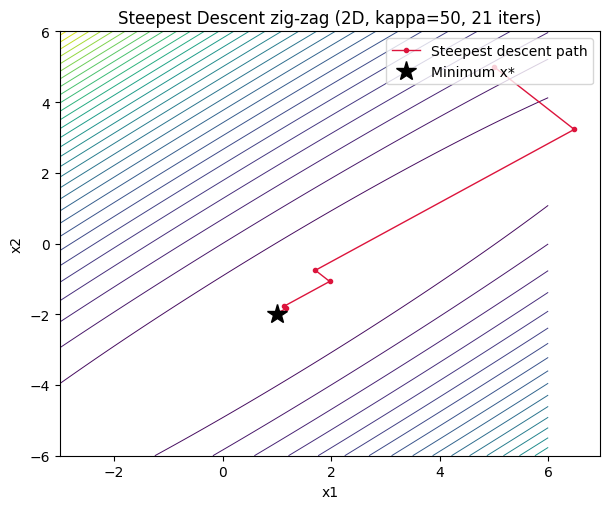

In [3]:
# --- 2D 지그재그 경로 (기하학적 직관, kappa=50) ---
A = make_spd(50, n=2, seed=1)
xstar = np.array([1.0, -2.0]); b = A @ xstar
x0 = np.array([5.0, 5.0])
xk, iters, path = steepest_descent(A, b, x0, tol=1e-6)

gx = np.linspace(-3, 6, 240); gy = np.linspace(-6, 6, 240)
GX, GY = np.meshgrid(gx, gy)
F = 0.5*(A[0,0]*GX**2 + 2*A[0,1]*GX*GY + A[1,1]*GY**2) - (b[0]*GX + b[1]*GY)

fig, ax = plt.subplots(figsize=(6.2, 5.2))
ax.contour(GX, GY, F, levels=30, cmap='viridis', linewidths=0.7)
ax.plot(path[:,0], path[:,1], '-o', color='crimson', ms=3, lw=1.0, label='Steepest descent path')
ax.plot(xstar[0], xstar[1], 'k*', ms=15, label='Minimum x*')
ax.set_xlabel('x1'); ax.set_ylabel('x2')
ax.set_title(f'Steepest Descent zig-zag (2D, kappa=50, {iters} iters)')
ax.legend(loc='upper right')
plt.tight_layout(); plt.show()

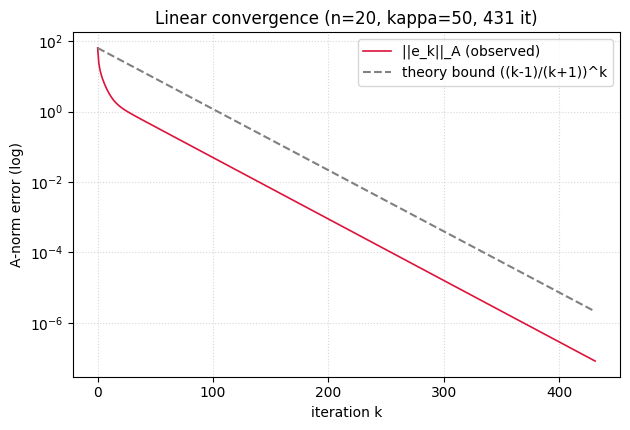

점근 축소인자(후반부) = 0.9606,  이론 (k-1)/(k+1) = 0.9608


In [4]:
# --- A-노름 오차의 선형 수렴 (n=20, kappa=50: 스펙트럼이 퍼져 이론율 실현) ---
A20 = make_spd(50, n=20, seed=7)
rng = np.random.default_rng(50)
xs20 = rng.standard_normal(20); b20 = A20 @ xs20
x020 = xs20 + 3.0 * rng.standard_normal(20)
xk20, it20, path20 = steepest_descent(A20, b20, x020, tol=1e-9*np.linalg.norm(b20))

errs = np.array([Anorm(p - xs20, A20) for p in path20])
factor = (50 - 1)/(50 + 1)
ref = errs[0] * factor**np.arange(len(errs))

fig, ax = plt.subplots(figsize=(6.4, 4.4))
ax.semilogy(errs, '-', color='crimson', lw=1.2, label='||e_k||_A (observed)')
ax.semilogy(ref, '--', color='gray', label='theory bound ((k-1)/(k+1))^k')
ax.set_xlabel('iteration k'); ax.set_ylabel('A-norm error (log)')
ax.set_title(f'Linear convergence (n=20, kappa=50, {it20} it)')
ax.legend(); ax.grid(True, which='both', ls=':', alpha=0.5)
plt.tight_layout(); plt.show()

half = errs[len(errs)//2:]
obs = np.exp(np.mean(np.diff(np.log(half[half>0]))))
print(f'점근 축소인자(후반부) = {obs:.4f},  이론 (k-1)/(k+1) = {factor:.4f}')

## 4. 결과 해석

1. **조건수 ↔ 반복수**: $n=20$ 스윕에서 $\kappa$ 가 커질수록 이론 수렴인자 $\frac{\kappa-1}{\kappa+1}$ 가 $1$ 에
   접근하고, 같은 tol 도달 반복수가 **단조 급증**한다($\kappa=2$ 수십 회 → $\kappa=500$ 수천 회).
2. **지그재그**: 정확한 직선탐색은 연속 잔차가 직교($\mathbf{r}_{k+1}\perp\mathbf{r}_k$)하게 만들어,
   가늘고 긴 골짜기에서 양 벽을 번갈아 때리는 90° 꺾임 경로가 된다. 골 바닥 방향으로 *직진*하지 못한다.
3. **선형 수렴**: $n=20,\ \kappa=50$ 에서 $\|\mathbf{e}_k\|_A$ 의 semilog 가 직선이고, 후반부 점근
   축소인자가 이론 $\frac{\kappa-1}{\kappa+1}=0.9608$ 과 거의 일치한다. (스펙트럼이 퍼져 있어 상한이 tight.)
4. **의미**: 최급강하는 *국소 정보(기울기)만* 쓰므로 안전·단순하지만, 곡률 비등방성(큰 $\kappa$)에
   취약하다. 이 약점이 다음 문제 **켤레기울기**의 동기다.

> **결론**: 최급강하법은 조건수에 지배되는 **선형 수렴** — $\kappa$ 가 크면 지그재그로 느려진다.

**다음 문제로의 연결**: CE_13_2_02 에서 **켤레기울기(CG)** 가 같은 SPD 이차형식을 *유한 스텝*(≤ $n$)에
끝내며 지그재그를 제거하는 것을 본다.